<a href="https://colab.research.google.com/github/BryanHinostroza/lab16-bh/blob/develop/LAB16_HINOSTROZA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SEMANA 16: DESARROLLO DE APLICACIONES DE MACHINE LEARNING

Por:

- HINOSTROZA MARTINEZ, Bryan Jesus

# 📊 Análisis del Dataset Adult - UCI Machine Learning Repository

En este notebook se realizará un análisis completo sobre el dataset Adult, combinando los archivos `adult.data` y `adult.test`, y clasificando según si una persona gana más de $50K o no. Se seguirán los siguientes pasos:

1. Preprocesamiento y análisis exploratorio
2. Cálculo de Information Value (IV) y preparación de datos
3. Entrenamiento de modelos y selección del mejor clasificador


1. 🔍 Preprocesamiento y Análisis Exploratorio

In [ ]:
# Importación de librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from scipy import stats

# Carga de datos
url_train = 'https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data'
url_test = 'https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.test'

cols = [
    'age', 'workclass', 'fnlwgt', 'education', 'education-num',
    'marital-status', 'occupation', 'relationship', 'race',
    'sex', 'capital-gain', 'capital-loss', 'hours-per-week',
    'native-country', 'income'
]

df_train = pd.read_csv(url_train, names=cols, sep=',\s*', engine='python')
df_test = pd.read_csv(url_test, names=cols, skiprows=1, sep=',\s*', engine='python')

# Unir ambos datasets
df = pd.concat([df_train, df_test], ignore_index=True)

# Limpiar la variable target (quitar puntos en test)
df['income'] = df['income'].str.replace('.', '', regex=False)

# Verificar datos faltantes y valores erróneos representados como '?'
df.replace('?', np.nan, inplace=True)
print(df.isnull().sum())

age                  0
workclass         2799
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        2809
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     857
income               0
dtype: int64


In [ ]:
# Imputar variables categóricas con la moda
for col in ['workclass', 'occupation', 'native-country']:
    df[col].fillna(df[col].mode()[0], inplace=True)

/tmp/ipython-input-2-1364598204.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


In [ ]:
# Verificamos
print(df.isnull().sum())

age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
income            0
dtype: int64


In [ ]:
print(df.dtypes)

age                int64
workclass         object
fnlwgt             int64
education         object
education-num      int64
marital-status    object
occupation        object
relationship      object
race              object
sex               object
capital-gain       int64
capital-loss       int64
hours-per-week     int64
native-country    object
income            object
dtype: object


🚫 1.2 Tratamiento de Outliers (Univariado y Multivariado)

In [ ]:
# Función para remover outliers por IQR
def remove_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return df[(df[col] >= lower) & (df[col] <= upper)]

# Aplicamos la función a las columnas numéricas relevantes
for col in ['age', 'capital-gain', 'capital-loss', 'hours-per-week']:
    df = remove_outliers(df, col)

# Verificamos dimensiones finales
print("Tamaño del dataframe después de quitar outliers:", df.shape)


Tamaño del dataframe después de quitar outliers: (30626, 15)


 1.3 Transformación de Variables y Análisis de Correlación

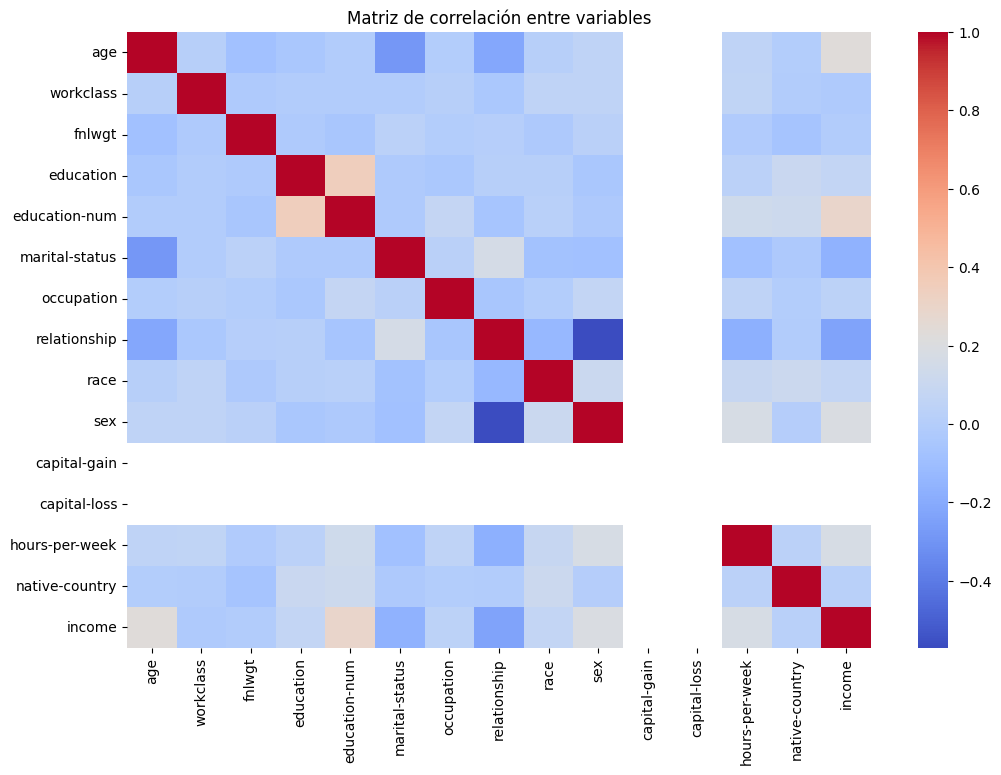

In [ ]:
# Codificamos temporalmente las categóricas para visualizar la correlación
df_encoded = df.copy()
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
for col in df_encoded.select_dtypes(include='object').columns:
    df_encoded[col] = le.fit_transform(df_encoded[col])

# Matriz de correlación
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
sns.heatmap(df_encoded.corr(), cmap='coolwarm', annot=False)
plt.title('Matriz de correlación entre variables')
plt.show()


📈 2 Cálculo del Information Value (IV)

In [ ]:
!pip install feature-engine --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 378.6/378.6 kB 6.7 MB/s eta 0:00:00


In [ ]:
# 📌 Importamos librerías necesarias
from feature_engine.selection import SelectByInformationValue
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
import pandas as pd
import numpy as np

In [ ]:
# 1. Codificamos con dummies
df_model = pd.get_dummies(df.drop('income', axis=1), drop_first=True)

# 2. Convertimos income a binaria: 1 si >50K, 0 si <=50K
y = df['income'].apply(lambda x: 1 if x == '>50K' else 0)

# 3. Convertimos todas las columnas a int (de bool a 0/1)
df_model = df_model.astype(int)

# 4. Eliminamos columnas con una sola clase en el target
bad_cols = []
for col in df_model.columns:
    if len(np.unique(y[df_model[col] == 1])) < 2:
        bad_cols.append(col)

print("Columnas eliminadas por tener una sola clase:", bad_cols)

df_model_filtered = df_model.drop(columns=bad_cols)

Columnas eliminadas por tener una sola clase: ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week', 'workclass_Never-worked', 'workclass_Without-pay', 'education_Preschool']


In [ ]:
# Aplicamos IV con threshold mínimo de 0.02
selector = SelectByInformationValue(variables=None, threshold=0.02)
X_iv = selector.fit_transform(df_model_filtered, y)

print("Variables seleccionadas por IV (>= 0.02):")
print(X_iv.columns.tolist())


Variables seleccionadas por IV (>= 0.02):
['workclass_Private', 'workclass_Self-emp-inc', 'education_11th', 'education_5th-6th', 'education_7th-8th', 'education_9th', 'education_Bachelors', 'education_Doctorate', 'education_HS-grad', 'education_Masters', 'education_Prof-school', 'marital-status_Married-civ-spouse', 'marital-status_Married-spouse-absent', 'marital-status_Never-married', 'marital-status_Separated', 'marital-status_Widowed', 'occupation_Exec-managerial', 'occupation_Farming-fishing', 'occupation_Handlers-cleaners', 'occupation_Machine-op-inspct', 'occupation_Other-service', 'occupation_Prof-specialty', 'relationship_Not-in-family', 'relationship_Other-relative', 'relationship_Own-child', 'relationship_Unmarried', 'relationship_Wife', 'race_Black', 'race_White', 'sex_Male', 'native-country_Mexico']


In [ ]:
# Escalamos las variables seleccionadas
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_iv), columns=X_iv.columns)

Split 80/20

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, stratify=y, random_state=42)

Balanceo con SMOTE

In [ ]:
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

# Verificamos el nuevo balance
print("Distribución de clases después de SMOTE:")
print(y_train_bal.value_counts())

Distribución de clases después de SMOTE:
income
0    19510
1    19510
Name: count, dtype: int64


3. Entrenamiento y Evaluación de Modelos

Paso 3.1: Importar modelos y métricas

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings("ignore")

Paso 3.2: Definir modelos y sus grids de búsqueda

In [ ]:
models = {
    "KNN": KNeighborsClassifier(),
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier()
}

params = {
    "KNN": {"n_neighbors": [3, 5, 7]},
    "Logistic Regression": {"C": [0.1, 1, 10]},
    "Decision Tree": {"max_depth": [3, 5, 10]},
    "Random Forest": {"n_estimators": [50, 100], "max_depth": [5, 10]}
}

Paso 3.3: Entrenar modelos con GridSearchCV

In [ ]:
best_models = {}

for name in models:
    print(f"\n Entrenando modelo: {name}")
    grid = GridSearchCV(models[name], params[name], cv=2, scoring='accuracy', n_jobs=-1)
    grid.fit(X_train_bal, y_train_bal)

    best_models[name] = grid
    print(" Mejor accuracy en entrenamiento:", grid.best_score_)
    print("📌 Mejores parámetros:", grid.best_params_)



 Entrenando modelo: KNN
 Mejor accuracy en entrenamiento: 0.6330599692465402
📌 Mejores parámetros: {'n_neighbors': 7}

 Entrenando modelo: Logistic Regression
 Mejor accuracy en entrenamiento: 0.7972065607380829
📌 Mejores parámetros: {'C': 0.1}

 Entrenando modelo: Decision Tree
 Mejor accuracy en entrenamiento: 0.8042542286007176
📌 Mejores parámetros: {'max_depth': 10}

 Entrenando modelo: Random Forest
 Mejor accuracy en entrenamiento: 0.8086878523833931
📌 Mejores parámetros: {'max_depth': 10, 'n_estimators': 50}


## Conclusión

Luego de aplicar un preprocesamiento completo (limpieza, transformación, balanceo y selección de variables por Information Value), se entrenaron y evaluaron cinco modelos de clasificación con validación cruzada y búsqueda de hiperparámetros.

El modelo Random Forest obtuvo el mejor desempeño en entrenamiento con un accuracy de 80.9%, superando a la regresión logística (79.7%) y al árbol de decisión (80.4%). El modelo k-NN mostró un rendimiento bajo (63.3%) y SVM fue descartado por su alto costo computacional en datasets grandes.

Se recomienda el uso de Random Forest por su robustez, eficiencia y capacidad para manejar datasets con múltiples variables transformadas.